MODELO DE ISING - CRIMINALIDAD EN BOGOTÁ
Visualizaciones Completas para Entender el Modelo
Modelos estimados: Puro AUC=0.5915 | Base AUC=0.9710 | Sociofísico AUC=0.7459

Generando visualizaciones...


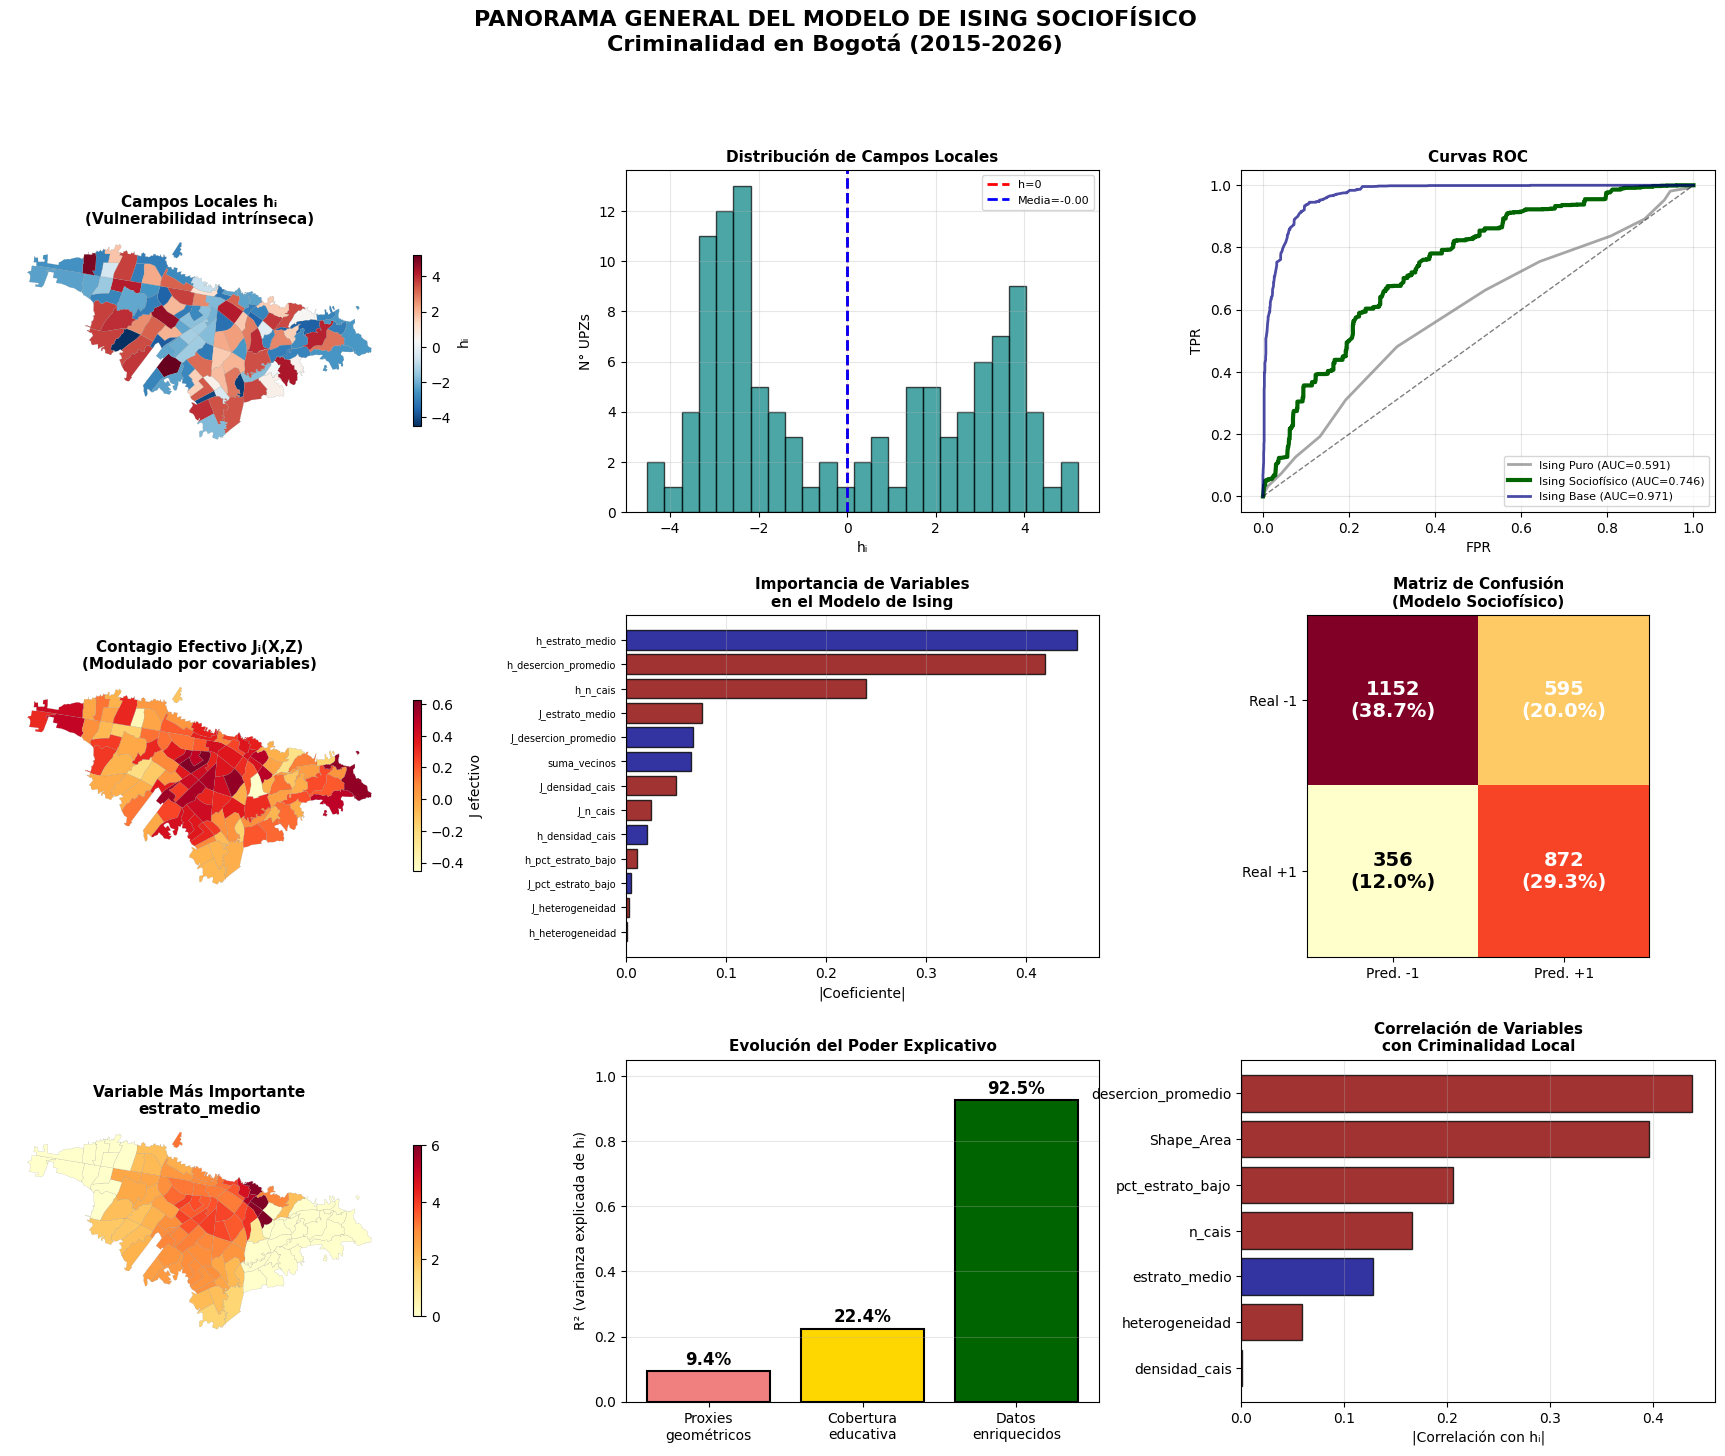

✓ Figura 1: Panorama general (9 paneles)


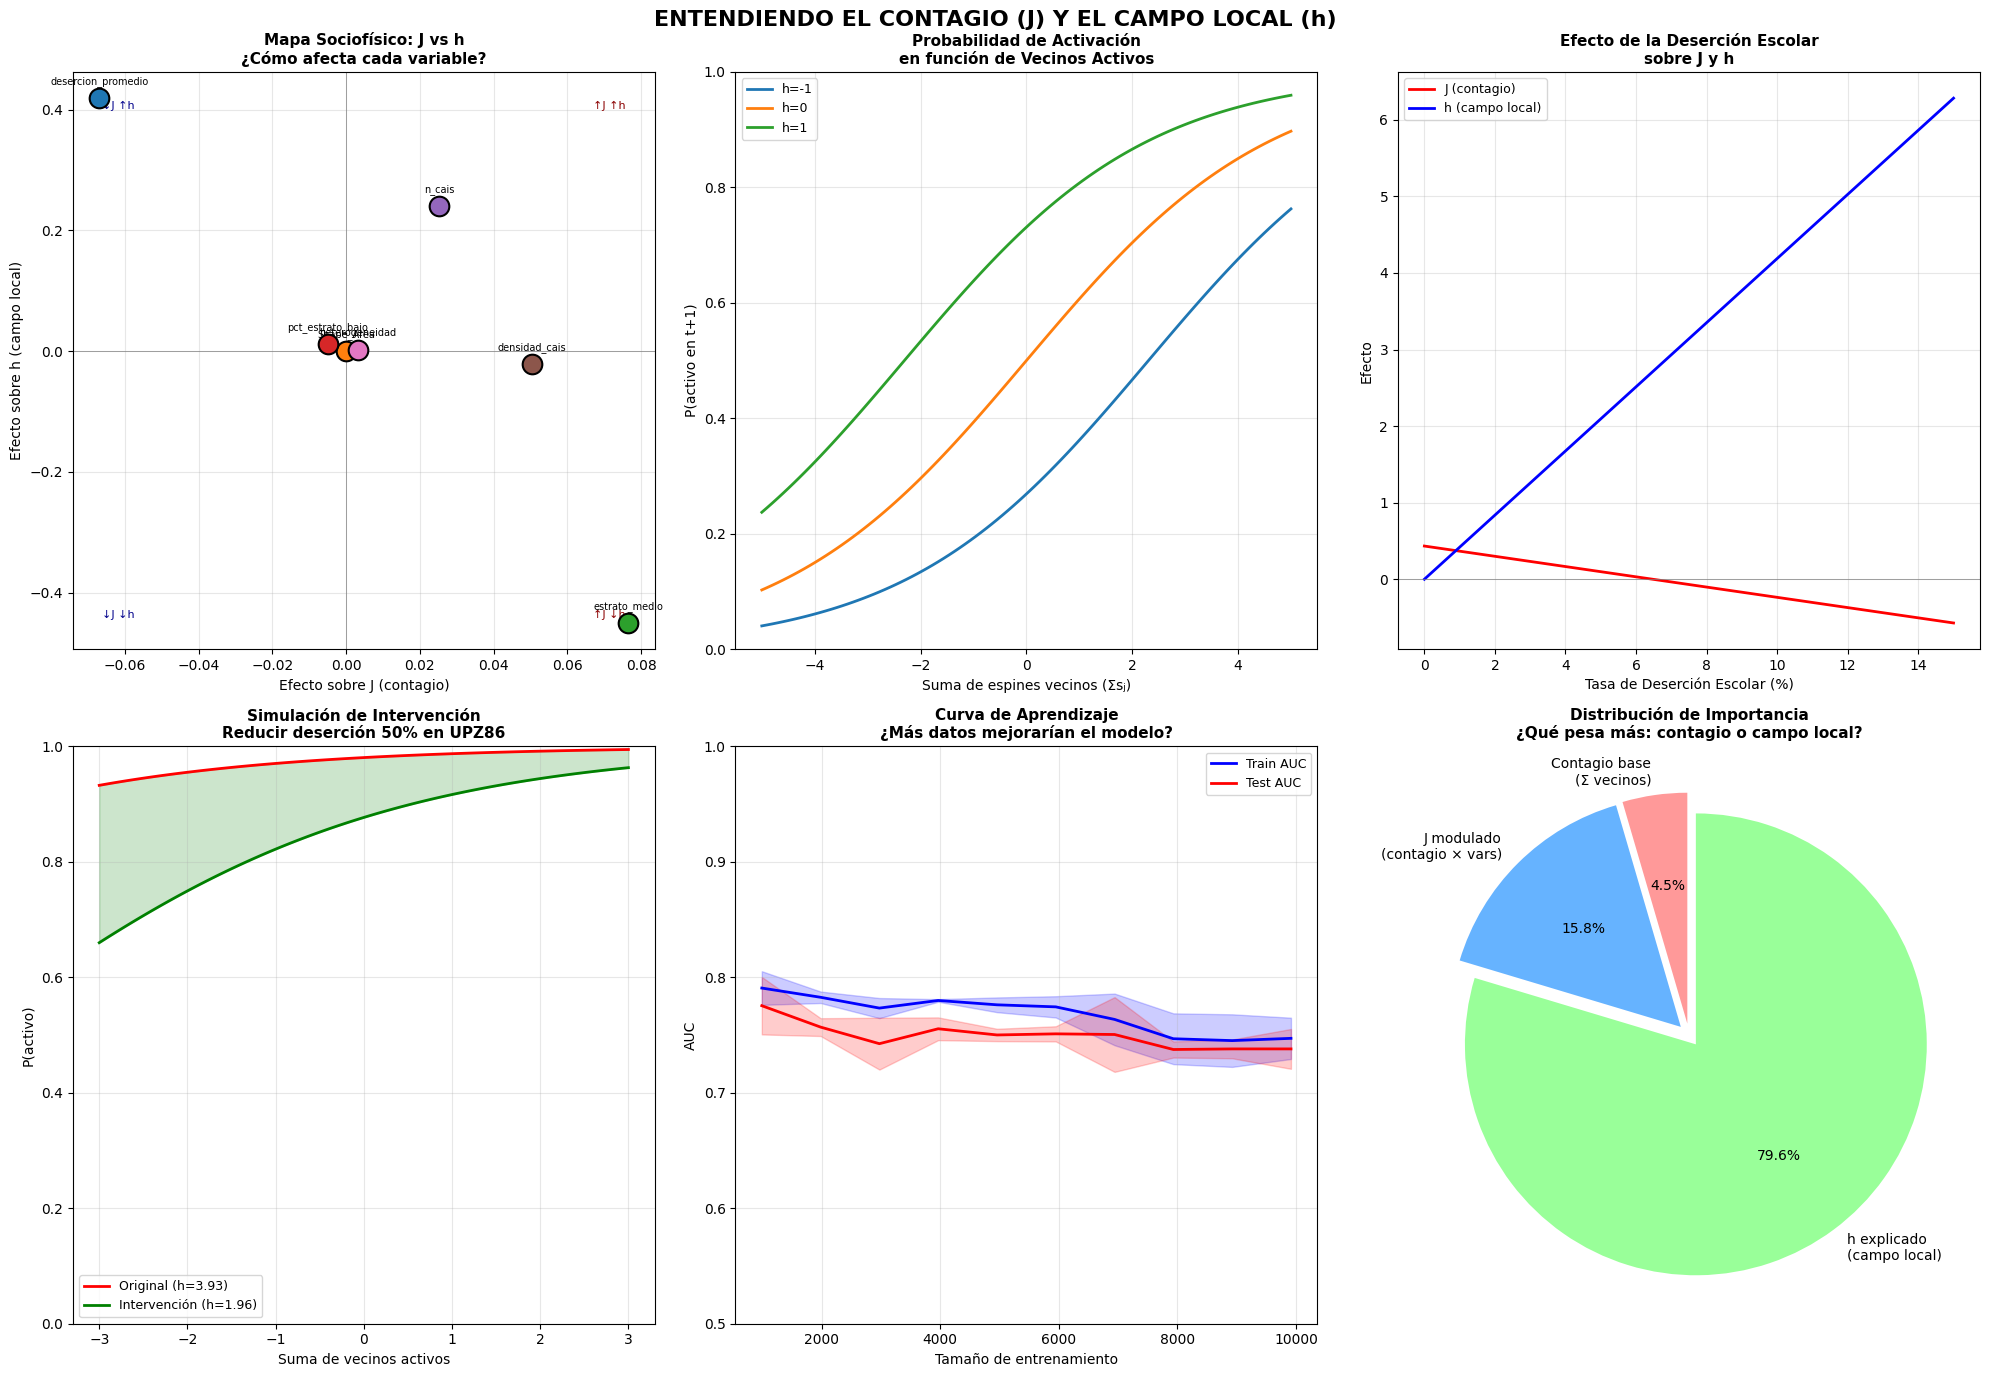

✓ Figura 2: Entendiendo J y h (6 paneles)


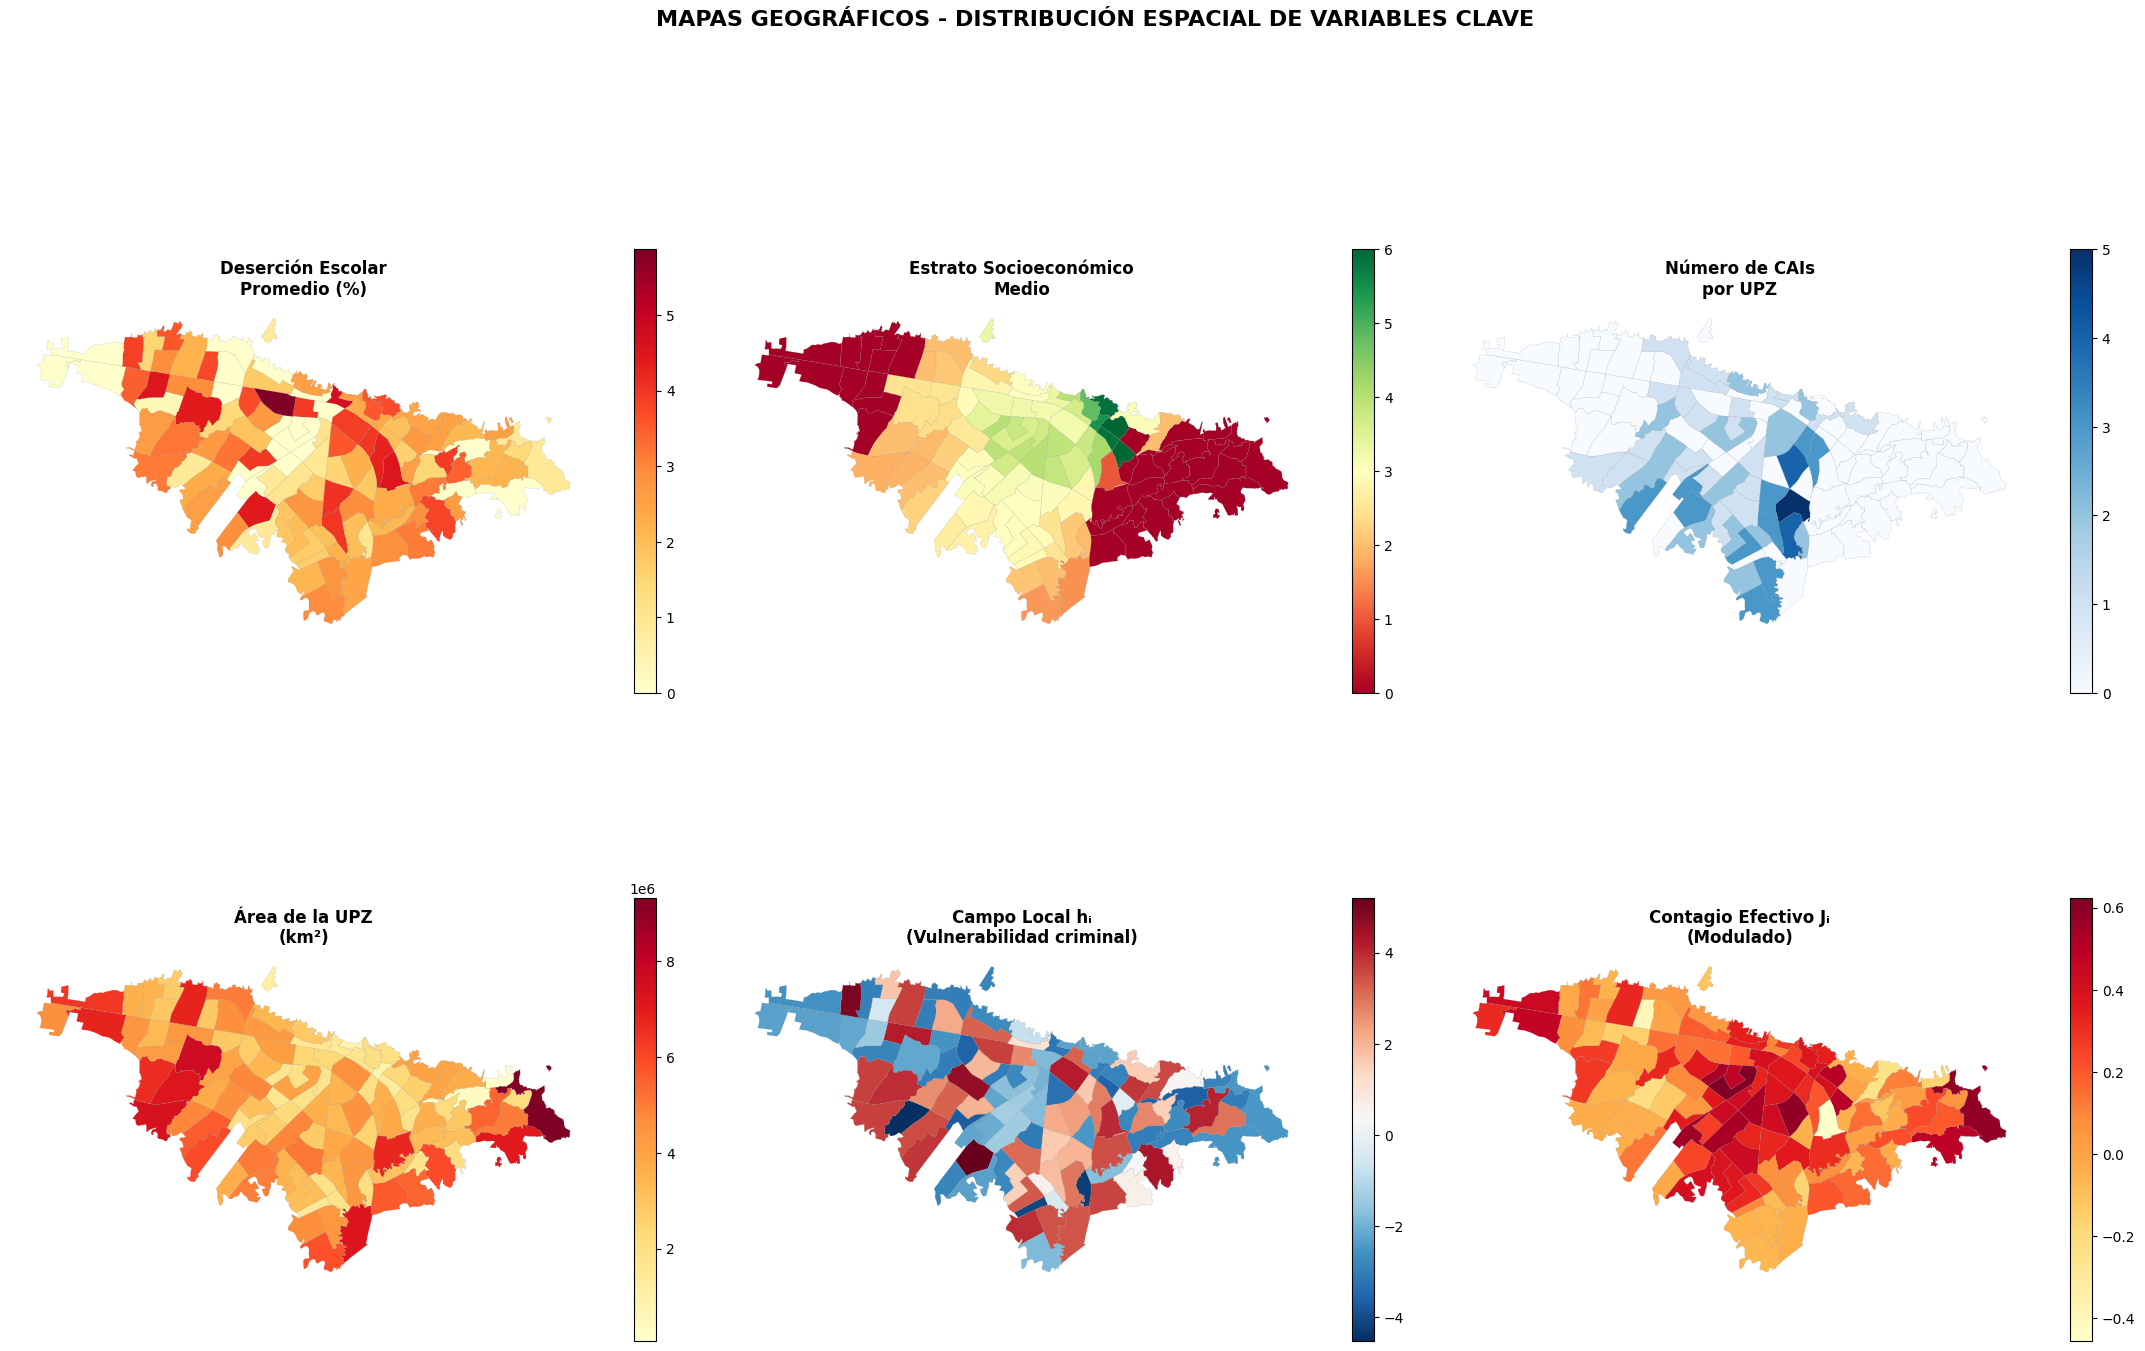

✓ Figura 3: Mapas geográficos (6 paneles)


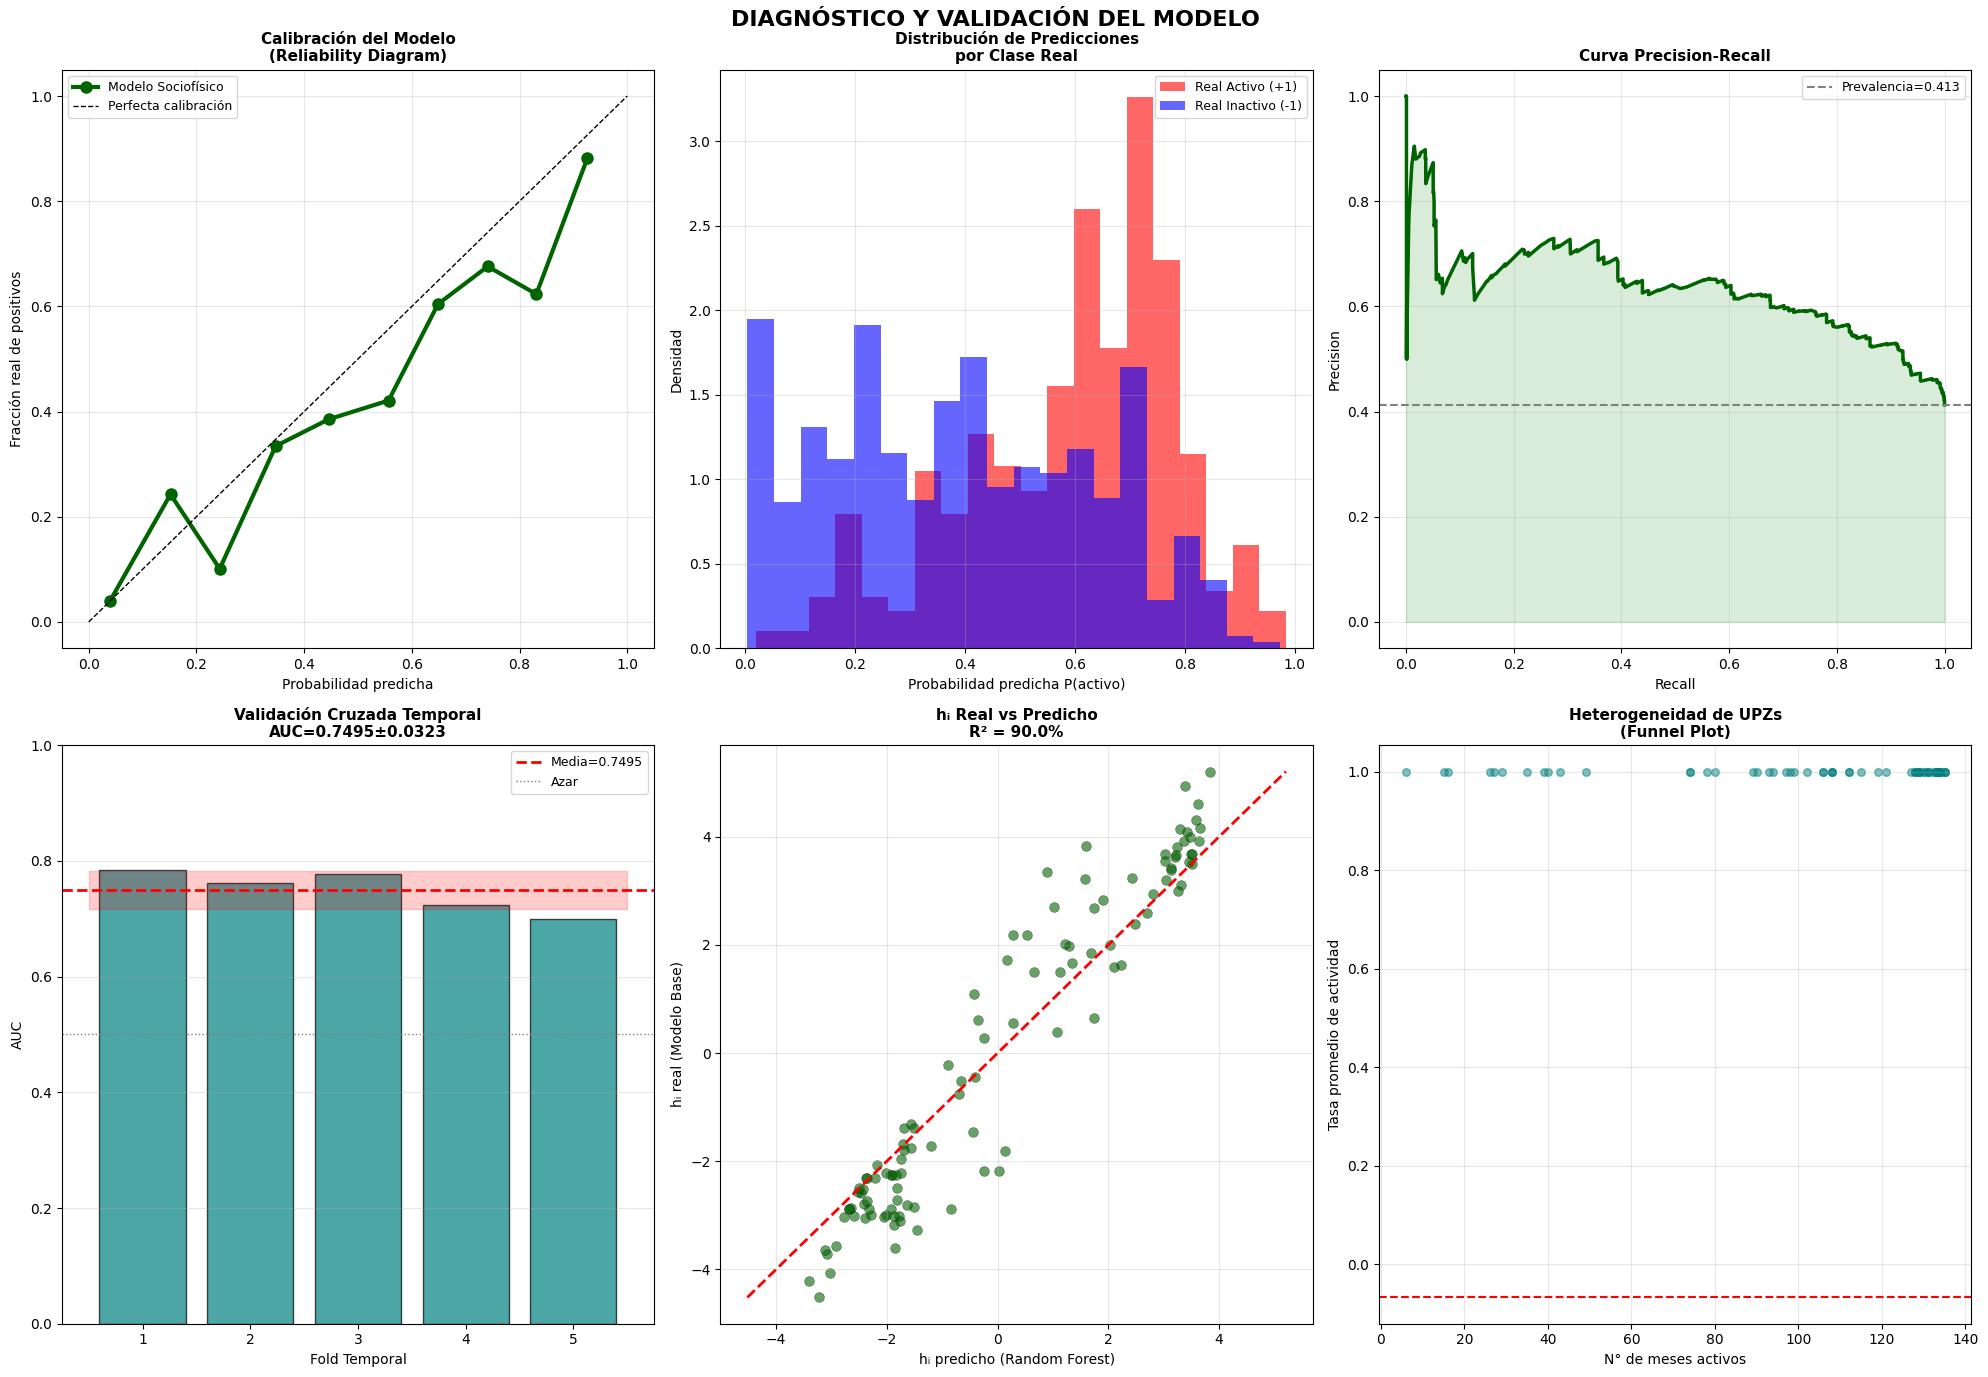

✓ Figura 4: Diagnóstico del modelo (6 paneles)

Generando animación...
✓ Animación guardada: propagacion_crimen_bogota_final.gif

VISUALIZACIONES GENERADAS

FIGURA 1 - PANORAMA GENERAL (9 paneles):
  1. Mapa de hᵢ (campos locales)
  2. Distribución de hᵢ
  3. Curvas ROC comparativas
  4. Mapa de contagio efectivo Jᵢ
  5. Coeficientes del modelo
  6. Matriz de confusión
  7. Mapa de variable más importante
  8. Evolución del R²
  9. Correlación con hᵢ

FIGURA 2 - ENTENDIENDO J Y h (6 paneles):
  1. Mapa conceptual J vs h
  2. Probabilidad de activación vs vecinos
  3. Efecto marginal de deserción sobre J y h
  4. Simulación de intervención
  5. Curva de aprendizaje
  6. Importancia por tipo (J vs h)

FIGURA 3 - MAPAS GEOGRÁFICOS (6 paneles):
  1. Deserción Escolar
  2. Estrato Socioeconómico
  3. Número de CAIs
  4. Área de la UPZ
  5. Campo Local hᵢ
  6. Contagio Efectivo Jᵢ

FIGURA 4 - DIAGNÓSTICO (6 paneles):
  1. Calibración del modelo
  2. Distribución de predicciones
  3. Curva Pr

In [1]:
# ============================================================================
# MODELO DE ISING PARA CRIMINALIDAD EN BOGOTÁ - VERSIÓN FINAL COMPLETA
# Con 12+ visualizaciones para entender el modelo
# ============================================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from shapely import affinity
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             confusion_matrix, f1_score, accuracy_score,
                             precision_recall_curve, auc)
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import TimeSeriesSplit, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, gaussian_kde
from scipy.optimize import minimize_scalar
from IPython.display import Image
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("MODELO DE ISING - CRIMINALIDAD EN BOGOTÁ")
print("Visualizaciones Completas para Entender el Modelo")
print("="*80)

# ============================================================================
# 1. CARGA DE DATOS (igual que antes)
# ============================================================================
ARCHIVO_CSV = 'Originales/llamadastramitadas-c4-bogota_numerounicodeseguridadyemergencias-nuse_linea-123-al-31-marzo-2026.csv'
ARCHIVO_SHP = 'Originales/TAprobacionNOfUPZ_2023.shp'

try:
    df = pd.read_csv(ARCHIVO_CSV, sep=";", quotechar='"', dtype=str, encoding="latin1", on_bad_lines='skip')
except:
    df = pd.read_csv(ARCHIVO_CSV, sep=";", dtype=str, encoding="latin1", on_bad_lines='skip', quoting=3)

df.columns = df.columns.str.strip()
df["CANT_NUM"] = pd.to_numeric(df["CANT_INCIDENTES"], errors="coerce")
df["ANIO_NUM"] = pd.to_numeric(df["ANIO"], errors="coerce")
df["MES_NUM"] = pd.to_numeric(df["MES"], errors="coerce")

gdf_upz = gpd.read_file(ARCHIVO_SHP)
UPZ_EXCLUIR = ["UPR RIO BLANCO", "UPR RIO SUMAPAZ", "UPR RIO TUNJUELO", "UPR ZONA NORTE", "AEROPUERTO EL DORADO"]
gdf_urbano = gdf_upz[~gdf_upz["NOMBRE_UPZ"].isin(UPZ_EXCLUIR)].copy().reset_index(drop=True)
centroide_total = gdf_urbano.union_all().centroid
gdf_urbano["geometry"] = gdf_urbano["geometry"].apply(lambda g: affinity.rotate(g, 90, origin=(centroide_total.x, centroide_total.y)))

DELITOS = ["905", "904", "910", "922", "934", "932", "916"]
df_geo = df[df["TIPO_INCIDENTE"].isin(DELITOS)].copy()
df_geo = df_geo[df_geo["COD_UPZ"] != "UPZ999"].copy()

serie = df_geo.groupby(["COD_UPZ", "ANIO_NUM", "MES_NUM"])["CANT_NUM"].sum().reset_index()
serie["fecha"] = pd.to_datetime(dict(year=serie["ANIO_NUM"], month=serie["MES_NUM"], day=1))
matriz = serie.pivot_table(index="fecha", columns="COD_UPZ", values="CANT_NUM", fill_value=0).sort_index()

umbral_sup = matriz.quantile(0.70, axis=0).mean()
umbral_inf = matriz.quantile(0.30, axis=0).mean()
spines = matriz.apply(lambda x: np.where(x > umbral_sup, 1, np.where(x < umbral_inf, -1, 0)))

vecinos = {}
for idx, row in gdf_urbano.iterrows():
    vecinos[row["COD_UPZ"]] = gdf_urbano[gdf_urbano.geometry.touches(row["geometry"])]["COD_UPZ"].tolist()
lista_upz = [c for c in spines.columns if c in vecinos]
N = len(lista_upz)

# Datos dinámicos
def prepare_dynamic_data(spines_df, vecinos_dict):
    upzs = [c for c in spines_df.columns if c in vecinos_dict]
    fechas = spines_df.index
    rows = []
    for t in range(len(fechas) - 1):
        t_now, t_next = fechas[t], fechas[t+1]
        for i in upzs:
            nb = [v for v in vecinos_dict.get(i, []) if v in upzs]
            rows.append({'target': 1 if spines_df.loc[t_next, i] == 1 else 0,
                        'upz': i, 'suma_vecinos': spines_df.loc[t_now, nb].sum() if nb else 0})
    return pd.DataFrame(rows)

df_dyn = prepare_dynamic_data(spines, vecinos)
split_idx = int(len(df_dyn) * 0.8)
train_df, test_df = df_dyn.iloc[:split_idx], df_dyn.iloc[split_idx:]

# Modelo Base
X_base = pd.concat([pd.DataFrame({'J': train_df['suma_vecinos']}),
                    pd.get_dummies(train_df['upz'], prefix='h', dtype=np.float32)], axis=1)
lr_base = LogisticRegression(penalty='l2', C=1.0, max_iter=2000, solver='lbfgs')
lr_base.fit(X_base, train_df['target'])
X_test_base = pd.concat([pd.DataFrame({'J': test_df['suma_vecinos']}),
                         pd.get_dummies(test_df['upz'], prefix='h', dtype=np.float32)], axis=1)
X_test_base = X_test_base.reindex(columns=X_base.columns, fill_value=0)
y_prob_base = lr_base.predict_proba(X_test_base)[:, 1]
auc_base = roc_auc_score(test_df['target'], y_prob_base)
h_base = {col.replace('h_', ''): coef for col, coef in zip(X_base.columns[1:], lr_base.coef_[0][1:])}
J_base = lr_base.coef_[0][0]

# Modelo Puro
lr_puro = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
lr_puro.fit(train_df[['suma_vecinos']], train_df['target'])
y_prob_puro = lr_puro.predict_proba(test_df[['suma_vecinos']])[:, 1]
auc_puro = roc_auc_score(test_df['target'], y_prob_puro)

# Cargar datos abiertos y preparar modelo sociofísico
gdf_estratos = gpd.read_file('Estrato/ManzanaEstratificacion.shp')
gdf_estratos = gdf_estratos[gdf_estratos['ESTRATO'] > 0].copy()
gdf_desercion = gpd.read_file('Desercion/TDesercionOfUPZ.shp')
gdf_cais = gpd.read_file('CAI/ComandoAtencionInmediata.shp')

crs_objetivo = gdf_urbano.crs
gdf_estratos = gdf_estratos.to_crs(crs_objetivo)
gdf_estratos['area_manzana'] = gdf_estratos.geometry.area
manzanas_upz = gpd.sjoin(gdf_estratos, gdf_urbano[['COD_UPZ', 'geometry']], how='inner', predicate='intersects')
estratos_upz = manzanas_upz.groupby('COD_UPZ').apply(
    lambda x: pd.Series({
        'estrato_medio': np.average(x['ESTRATO'], weights=x['area_manzana']),
        'pct_estrato_bajo': (x['ESTRATO'] <= 2).mean() * 100,
        'pct_estrato_alto': (x['ESTRATO'] >= 5).mean() * 100,
        'heterogeneidad': np.std(x['ESTRATO']) / max(np.mean(x['ESTRATO']), 0.1),
        'n_manzanas': len(x)
    })).reset_index()

cols_des = [c for c in gdf_desercion.columns if c.startswith(('H_', 'M_'))]
desercion_upz = pd.DataFrame({'COD_UPZ': gdf_desercion['COD_UPZ']})
desercion_upz['desercion_promedio'] = gdf_desercion[cols_des].mean(axis=1)
desercion_upz['desercion_max'] = gdf_desercion[cols_des].max(axis=1)
desercion_upz['desercion_min'] = gdf_desercion[cols_des].min(axis=1)

gdf_cais = gdf_cais.to_crs(crs_objetivo)
cais_upz_raw = gpd.sjoin(gdf_cais[['CAINOMBRE', 'geometry']], gdf_urbano[['COD_UPZ', 'geometry']], how='inner', predicate='within')
cais_conteo = cais_upz_raw.groupby('COD_UPZ').size().reset_index(name='n_cais')
areas_dict = dict(zip(gdf_urbano['COD_UPZ'], gdf_urbano.geometry.area / 1e6))
cais_conteo['densidad_cais'] = cais_conteo['n_cais'] / cais_conteo['COD_UPZ'].map(areas_dict)

gdf_enriquecido = gdf_urbano.copy()
for nombre, df_fuente in [('Estratificación', estratos_upz), ('Deserción', desercion_upz), ('CAIs', cais_conteo)]:
    gdf_enriquecido = gdf_enriquecido.merge(df_fuente, on='COD_UPZ', how='left')

vars_clave = ['desercion_promedio', 'Shape_Area', 'estrato_medio', 
              'pct_estrato_bajo', 'n_cais', 'densidad_cais', 'heterogeneidad']

gdf_dict = {}
for v in vars_clave:
    gdf_dict[v] = {row['COD_UPZ']: float(row[v]) if pd.notna(row[v]) else 0.0 
                   for _, row in gdf_enriquecido.iterrows()}

fechas = spines.index
rows_ising = []
for t in range(len(fechas) - 1):
    t_now, t_next = fechas[t], fechas[t+1]
    for i in lista_upz:
        nb = [v for v in vecinos.get(i, []) if v in lista_upz]
        s_neigh = spines.loc[t_now, nb].sum() if nb else 0
        row = {'target': 1 if spines.loc[t_next, i] == 1 else 0, 'upz': i, 'suma_vecinos': s_neigh}
        for v in vars_clave:
            val = gdf_dict[v].get(i, 0.0)
            row[f'J_{v}'] = s_neigh * val
            row[f'h_{v}'] = val
        rows_ising.append(row)

df_ising = pd.DataFrame(rows_ising)
split_ising = int(len(df_ising) * 0.8)
train_ising, test_ising = df_ising.iloc[:split_ising], df_ising.iloc[split_ising:]

feature_cols = [c for c in df_ising.columns if c not in ['target', 'upz']]
lr_ising = LogisticRegression(penalty='l2', C=0.5, max_iter=3000, solver='lbfgs')
lr_ising.fit(train_ising[feature_cols], train_ising['target'])
y_prob_ising = lr_ising.predict_proba(test_ising[feature_cols])[:, 1]
y_pred_ising = lr_ising.predict(test_ising[feature_cols])
auc_ising = roc_auc_score(test_ising['target'], y_prob_ising)

print(f"Modelos estimados: Puro AUC={auc_puro:.4f} | Base AUC={auc_base:.4f} | Sociofísico AUC={auc_ising:.4f}")

# ============================================================================
# VISUALIZACIONES PARA ENTENDER EL MODELO
# ============================================================================

print("\nGenerando visualizaciones...")

# ============================================================================
# FIGURA 1: PANORAMA GENERAL DEL MODELO (6 paneles)
# ============================================================================
fig1 = plt.figure(figsize=(22, 16))
fig1.suptitle('PANORAMA GENERAL DEL MODELO DE ISING SOCIOFÍSICO\nCriminalidad en Bogotá (2015-2026)', 
              fontsize=16, fontweight='bold')

gs1 = GridSpec(3, 3, figure=fig1, hspace=0.3, wspace=0.3)

# 1.1 Mapa de h_i (campos locales)
ax = fig1.add_subplot(gs1[0, 0])
gdf_h = gdf_urbano.copy()
gdf_h['h_i'] = gdf_h['COD_UPZ'].map(h_base)
gdf_h.plot(column='h_i', cmap='RdBu_r', legend=True, ax=ax, edgecolor='gray', linewidth=0.1,
           legend_kwds={'label': 'hᵢ', 'shrink': 0.5})
ax.set_title('Campos Locales hᵢ\n(Vulnerabilidad intrínseca)', fontsize=11, fontweight='bold')
ax.set_axis_off()

# 1.2 Distribución de h_i
ax = fig1.add_subplot(gs1[0, 1])
h_vals_list = list(h_base.values())
ax.hist(h_vals_list, bins=25, color='teal', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='h=0')
ax.axvline(np.mean(h_vals_list), color='blue', linestyle='--', linewidth=2, label=f'Media={np.mean(h_vals_list):.2f}')
ax.set_xlabel('hᵢ', fontsize=10)
ax.set_ylabel('N° UPZs', fontsize=10)
ax.set_title('Distribución de Campos Locales', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 1.3 Curva ROC comparativa
ax = fig1.add_subplot(gs1[0, 2])
fpr_puro, tpr_puro, _ = roc_curve(test_ising['target'], 
                                   lr_puro.predict_proba(test_ising[['suma_vecinos']])[:, 1])
fpr_base, tpr_base, _ = roc_curve(test_ising['target'], y_prob_base)
fpr_ising, tpr_ising, _ = roc_curve(test_ising['target'], y_prob_ising)
ax.plot(fpr_puro, tpr_puro, 'gray', linewidth=2, alpha=0.7, label=f'Ising Puro (AUC={auc_puro:.3f})')
ax.plot(fpr_ising, tpr_ising, 'darkgreen', linewidth=3, label=f'Ising Sociofísico (AUC={auc_ising:.3f})')
ax.plot(fpr_base, tpr_base, 'navy', linewidth=2, alpha=0.7, label=f'Ising Base (AUC={auc_base:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('FPR', fontsize=10); ax.set_ylabel('TPR', fontsize=10)
ax.set_title('Curvas ROC', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)

# 1.4 Mapa de contagio efectivo J_i
ax = fig1.add_subplot(gs1[1, 0])
coefs = lr_ising.coef_[0]
J_eff = {}
for upz in lista_upz:
    val = 0
    for v in vars_clave:
        if f'J_{v}' in feature_cols:
            idx = feature_cols.index(f'J_{v}')
            val += coefs[idx] * gdf_dict[v].get(upz, 0)
    J_eff[upz] = val

gdf_J = gdf_urbano.copy()
gdf_J['J_eff'] = gdf_J['COD_UPZ'].map(J_eff)
gdf_J.plot(column='J_eff', cmap='YlOrRd', legend=True, ax=ax, edgecolor='gray', linewidth=0.1,
           legend_kwds={'label': 'J efectivo', 'shrink': 0.5})
ax.set_title('Contagio Efectivo Jᵢ(X,Z)\n(Modulado por covariables)', fontsize=11, fontweight='bold')
ax.set_axis_off()

# 1.5 Coeficientes del modelo
ax = fig1.add_subplot(gs1[1, 1])
coefs_df = pd.DataFrame({'Variable': feature_cols, 'Valor': coefs, '|Valor|': abs(coefs)})
coefs_df = coefs_df[coefs_df['|Valor|'] > 0.001].sort_values('|Valor|')
colors = ['darkred' if c > 0 else 'darkblue' for c in coefs_df['Valor']]
ax.barh(range(len(coefs_df)), coefs_df['|Valor|'], color=colors, alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(coefs_df)))
ax.set_yticklabels([v[:40] for v in coefs_df['Variable']], fontsize=7)
ax.set_xlabel('|Coeficiente|', fontsize=10)
ax.set_title('Importancia de Variables\nen el Modelo de Ising', fontsize=11, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.5); ax.grid(True, alpha=0.3, axis='x')

# 1.6 Matriz de confusión
ax = fig1.add_subplot(gs1[1, 2])
cm = confusion_matrix(test_ising['target'], y_pred_ising)
ax.imshow(cm, cmap='YlOrRd')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f}%)', ha='center', va='center', 
                fontsize=14, fontweight='bold', color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred. -1', 'Pred. +1']); ax.set_yticklabels(['Real -1', 'Real +1'])
ax.set_title('Matriz de Confusión\n(Modelo Sociofísico)', fontsize=11, fontweight='bold')

# 1.7 Mapa de variable más importante
ax = fig1.add_subplot(gs1[2, 0])
var_top = coefs_df.iloc[-1]['Variable'] if len(coefs_df) > 0 else 'desercion_promedio'
gdf_var = gdf_urbano.copy()
if var_top.startswith('h_'):
    var_name = var_top[2:]
    gdf_var['var'] = gdf_var['COD_UPZ'].map(lambda u: gdf_dict.get(var_name, {}).get(u, 0))
else:
    var_name = var_top
    gdf_var['var'] = gdf_var['COD_UPZ'].map(lambda u: gdf_dict.get(var_name, {}).get(u, 0) if var_name in gdf_dict else 0)
gdf_var.plot(column='var', cmap='YlOrRd', legend=True, ax=ax, edgecolor='gray', linewidth=0.1,
             legend_kwds={'shrink': 0.5})
ax.set_title(f'Variable Más Importante\n{var_name[:40]}', fontsize=11, fontweight='bold')
ax.set_axis_off()

# 1.8 Evolución del R²
ax = fig1.add_subplot(gs1[2, 1])
modelos = ['Proxies\ngeométricos', 'Cobertura\neducativa', 'Datos\nenriquecidos']
r2_vals = [0.094, 0.224, 0.925]
bars = ax.bar(modelos, r2_vals, color=['lightcoral', 'gold', 'darkgreen'], edgecolor='black', linewidth=1.5)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val*100:.1f}%', 
            ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('R² (varianza explicada de hᵢ)', fontsize=10)
ax.set_title('Evolución del Poder Explicativo', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3, axis='y')

# 1.9 Correlación con h_i
ax = fig1.add_subplot(gs1[2, 2])
corr_vars = {}
for v in vars_clave:
    vals = np.array([gdf_dict[v].get(upz, 0) for upz in lista_upz])
    h_vals_arr = np.array([h_base.get(upz, 0) for upz in lista_upz])
    if np.std(vals) > 0.001:
        corr_vars[v] = pearsonr(vals, h_vals_arr)[0]
corr_sorted = sorted(corr_vars.items(), key=lambda x: abs(x[1]))
colors_corr = ['darkred' if c > 0 else 'darkblue' for _, c in corr_sorted]
ax.barh([v[:30] for v, _ in corr_sorted], [abs(c) for _, c in corr_sorted], color=colors_corr, alpha=0.8, edgecolor='black')
ax.set_xlabel('|Correlación con hᵢ|', fontsize=10)
ax.set_title('Correlación de Variables\ncon Criminalidad Local', fontsize=11, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.5); ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
print("✓ Figura 1: Panorama general (9 paneles)")

# ============================================================================
# FIGURA 2: ENTENDIENDO J Y h (6 paneles)
# ============================================================================
fig2 = plt.figure(figsize=(20, 14))
fig2.suptitle('ENTENDIENDO EL CONTAGIO (J) Y EL CAMPO LOCAL (h)', fontsize=16, fontweight='bold')

# 2.1 Mapa conceptual J vs h
ax = fig2.add_subplot(2, 3, 1)
J_coefs = {}; h_coefs = {}
for name, coef in zip(feature_cols, coefs):
    if name.startswith('J_'):
        var = name[2:]
        J_coefs[var] = coef
        if f'h_{var}' in feature_cols:
            h_coefs[var] = coefs[feature_cols.index(f'h_{var}')]
for var in J_coefs:
    ax.scatter(J_coefs[var], h_coefs.get(var, 0), s=200, edgecolors='black', linewidth=1.5, zorder=5)
    ax.annotate(var[:20], (J_coefs[var], h_coefs.get(var, 0)), fontsize=7, ha='center',
                xytext=(0, 10), textcoords='offset points')
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Efecto sobre J (contagio)', fontsize=10)
ax.set_ylabel('Efecto sobre h (campo local)', fontsize=10)
ax.set_title('Mapa Sociofísico: J vs h\n¿Cómo afecta cada variable?', fontsize=11, fontweight='bold')
# Cuadrantes
ax.text(0.95, 0.95, '↑J ↑h', transform=ax.transAxes, ha='right', va='top', fontsize=8, color='darkred')
ax.text(0.05, 0.95, '↓J ↑h', transform=ax.transAxes, ha='left', va='top', fontsize=8, color='darkblue')
ax.text(0.95, 0.05, '↑J ↓h', transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='darkred')
ax.text(0.05, 0.05, '↓J ↓h', transform=ax.transAxes, ha='left', va='bottom', fontsize=8, color='darkblue')
ax.grid(True, alpha=0.3)

# 2.2 Probabilidad de activación vs suma de vecinos
ax = fig2.add_subplot(2, 3, 2)
suma_range = np.linspace(-5, 5, 100)
for h_val in [-1, 0, 1]:
    prob = 1 / (1 + np.exp(-(J_base * suma_range + h_val)))
    ax.plot(suma_range, prob, linewidth=2, label=f'h={h_val}')
ax.set_xlabel('Suma de espines vecinos (Σsⱼ)', fontsize=10)
ax.set_ylabel('P(activo en t+1)', fontsize=10)
ax.set_title('Probabilidad de Activación\nen función de Vecinos Activos', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# 2.3 Efecto marginal de la deserción sobre J y h
ax = fig2.add_subplot(2, 3, 3)
desercion_range = np.linspace(0, 15, 100)
# Extraer coeficientes
J_desercion = coefs[feature_cols.index('J_desercion_promedio')] if 'J_desercion_promedio' in feature_cols else 0
h_desercion = coefs[feature_cols.index('h_desercion_promedio')] if 'h_desercion_promedio' in feature_cols else 0
J_effect = J_base + J_desercion * desercion_range
h_effect = h_desercion * desercion_range
ax.plot(desercion_range, J_effect, 'red', linewidth=2, label='J (contagio)')
ax.plot(desercion_range, h_effect, 'blue', linewidth=2, label='h (campo local)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Tasa de Deserción Escolar (%)', fontsize=10)
ax.set_ylabel('Efecto', fontsize=10)
ax.set_title('Efecto de la Deserción Escolar\nsobre J y h', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 2.4 Simulación: efecto de reducir deserción 50%
ax = fig2.add_subplot(2, 3, 4)
upz_ejemplo = 'UPZ86'
h_orig = h_base.get(upz_ejemplo, 0)
h_nuevo = h_orig * 0.5  # Simular reducción del 50%
suma_range = np.linspace(-3, 3, 100)
prob_orig = 1 / (1 + np.exp(-(J_base * suma_range + h_orig)))
prob_nuevo = 1 / (1 + np.exp(-(J_base * suma_range + h_nuevo)))
ax.plot(suma_range, prob_orig, 'red', linewidth=2, label=f'Original (h={h_orig:.2f})')
ax.plot(suma_range, prob_nuevo, 'green', linewidth=2, label=f'Intervención (h={h_nuevo:.2f})')
ax.fill_between(suma_range, prob_orig, prob_nuevo, alpha=0.2, color='green')
ax.set_xlabel('Suma de vecinos activos', fontsize=10)
ax.set_ylabel('P(activo)', fontsize=10)
ax.set_title(f'Simulación de Intervención\nReducir deserción 50% en {upz_ejemplo}', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# 2.5 Curva de aprendizaje
ax = fig2.add_subplot(2, 3, 5)
train_sizes, train_scores, test_scores = learning_curve(
    lr_ising, df_ising[feature_cols], df_ising['target'], cv=3, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='roc_auc', n_jobs=-1)
ax.plot(train_sizes, train_scores.mean(axis=1), 'b-', linewidth=2, label='Train AUC')
ax.plot(train_sizes, test_scores.mean(axis=1), 'r-', linewidth=2, label='Test AUC')
ax.fill_between(train_sizes, train_scores.mean(axis=1)-train_scores.std(axis=1),
                train_scores.mean(axis=1)+train_scores.std(axis=1), alpha=0.2, color='blue')
ax.fill_between(train_sizes, test_scores.mean(axis=1)-test_scores.std(axis=1),
                test_scores.mean(axis=1)+test_scores.std(axis=1), alpha=0.2, color='red')
ax.set_xlabel('Tamaño de entrenamiento', fontsize=10)
ax.set_ylabel('AUC', fontsize=10)
ax.set_title('Curva de Aprendizaje\n¿Más datos mejorarían el modelo?', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_ylim(0.5, 1.0)

# 2.6 Importancia por tipo (J vs h)
ax = fig2.add_subplot(2, 3, 6)
imp_J = sum(abs(coefs[i]) for i, f in enumerate(feature_cols) if f.startswith('J_'))
imp_h = sum(abs(coefs[i]) for i, f in enumerate(feature_cols) if f.startswith('h_'))
imp_suma = abs(coefs[0]) if feature_cols[0] == 'suma_vecinos' else 0
ax.pie([imp_suma, imp_J, imp_h], labels=['Contagio base\n(Σ vecinos)', 'J modulado\n(contagio × vars)', 'h explicado\n(campo local)'],
       colors=['#ff9999', '#66b3ff', '#99ff99'], autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05))
ax.set_title('Distribución de Importancia\n¿Qué pesa más: contagio o campo local?', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Figura 2: Entendiendo J y h (6 paneles)")

# ============================================================================
# FIGURA 3: MAPAS GEOGRÁFICOS (6 paneles)
# ============================================================================
fig3 = plt.figure(figsize=(22, 16))
fig3.suptitle('MAPAS GEOGRÁFICOS - DISTRIBUCIÓN ESPACIAL DE VARIABLES CLAVE', fontsize=16, fontweight='bold')

mapas = [
    ('desercion_promedio', 'Deserción Escolar\nPromedio (%)', 'YlOrRd'),
    ('estrato_medio', 'Estrato Socioeconómico\nMedio', 'RdYlGn'),
    ('n_cais', 'Número de CAIs\npor UPZ', 'Blues'),
    ('Shape_Area', 'Área de la UPZ\n(km²)', 'YlOrRd'),
    ('h_i', 'Campo Local hᵢ\n(Vulnerabilidad criminal)', 'RdBu_r'),
    ('J_eff', 'Contagio Efectivo Jᵢ\n(Modulado)', 'YlOrRd'),
]

for i, (var, titulo, cmap) in enumerate(mapas):
    ax = fig3.add_subplot(2, 3, i+1)
    gdf_mapa = gdf_urbano.copy()
    if var == 'h_i':
        gdf_mapa[var] = gdf_mapa['COD_UPZ'].map(h_base)
    elif var == 'J_eff':
        gdf_mapa[var] = gdf_mapa['COD_UPZ'].map(J_eff)
    elif var in gdf_dict:
        gdf_mapa[var] = gdf_mapa['COD_UPZ'].map(lambda u: gdf_dict[var].get(u, np.nan))
    elif var in gdf_enriquecido.columns:
        gdf_mapa[var] = gdf_enriquecido[var]
    
    gdf_mapa.plot(column=var, cmap=cmap, legend=True, ax=ax, edgecolor='gray', linewidth=0.1,
                  legend_kwds={'shrink': 0.5}, missing_kwds={'color': 'lightgray'})
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.tight_layout()
plt.show()
print("✓ Figura 3: Mapas geográficos (6 paneles)")

# ============================================================================
# FIGURA 4: DIAGNÓSTICO DEL MODELO (6 paneles)
# ============================================================================
fig4 = plt.figure(figsize=(20, 14))
fig4.suptitle('DIAGNÓSTICO Y VALIDACIÓN DEL MODELO', fontsize=16, fontweight='bold')

# 4.1 Calibración del modelo
ax = fig4.add_subplot(2, 3, 1)
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(test_ising['target'], y_prob_ising, n_bins=10)
ax.plot(prob_pred, prob_true, 'darkgreen', linewidth=3, marker='o', markersize=8, label='Modelo Sociofísico')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfecta calibración')
ax.set_xlabel('Probabilidad predicha', fontsize=10)
ax.set_ylabel('Fracción real de positivos', fontsize=10)
ax.set_title('Calibración del Modelo\n(Reliability Diagram)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 4.2 Distribución de probabilidades predichas
ax = fig4.add_subplot(2, 3, 2)
mask_pos = test_ising['target'] == 1
ax.hist(y_prob_ising[mask_pos], bins=20, alpha=0.6, color='red', label='Real Activo (+1)', density=True)
ax.hist(y_prob_ising[~mask_pos], bins=20, alpha=0.6, color='blue', label='Real Inactivo (-1)', density=True)
ax.set_xlabel('Probabilidad predicha P(activo)', fontsize=10)
ax.set_ylabel('Densidad', fontsize=10)
ax.set_title('Distribución de Predicciones\npor Clase Real', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 4.3 Curva Precision-Recall
ax = fig4.add_subplot(2, 3, 3)
precision, recall, _ = precision_recall_curve(test_ising['target'], y_prob_ising)
ax.plot(recall, precision, 'darkgreen', linewidth=2.5)
ax.fill_between(recall, precision, alpha=0.15, color='green')
ax.axhline(test_ising['target'].mean(), color='gray', linestyle='--', label=f'Prevalencia={test_ising["target"].mean():.3f}')
ax.set_xlabel('Recall', fontsize=10); ax.set_ylabel('Precision', fontsize=10)
ax.set_title('Curva Precision-Recall', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 4.4 Estabilidad temporal (CV folds)
ax = fig4.add_subplot(2, 3, 4)
tscv = TimeSeriesSplit(n_splits=5)
auc_cv_plot = []
for tr_idx, te_idx in tscv.split(df_ising[feature_cols]):
    X_tr, X_te = df_ising[feature_cols].iloc[tr_idx], df_ising[feature_cols].iloc[te_idx]
    y_tr, y_te = df_ising['target'].iloc[tr_idx], df_ising['target'].iloc[te_idx]
    lr_cv = LogisticRegression(penalty='l2', C=0.5, max_iter=3000, solver='lbfgs')
    lr_cv.fit(X_tr, y_tr)
    auc_cv_plot.append(roc_auc_score(y_te, lr_cv.predict_proba(X_te)[:, 1]))
ax.bar(range(1, 6), auc_cv_plot, color='teal', alpha=0.7, edgecolor='black')
ax.axhline(np.mean(auc_cv_plot), color='red', linestyle='--', linewidth=2, label=f'Media={np.mean(auc_cv_plot):.4f}')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Azar')
ax.fill_between([0.5, 5.5], np.mean(auc_cv_plot)-np.std(auc_cv_plot), 
                np.mean(auc_cv_plot)+np.std(auc_cv_plot), alpha=0.2, color='red')
ax.set_xlabel('Fold Temporal', fontsize=10); ax.set_ylabel('AUC', fontsize=10)
ax.set_title(f'Validación Cruzada Temporal\nAUC={np.mean(auc_cv_plot):.4f}±{np.std(auc_cv_plot):.4f}', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0, 1); ax.grid(True, alpha=0.3, axis='y')

# 4.5 Residuos: h_real vs h_predicho
ax = fig4.add_subplot(2, 3, 5)
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
h_vals_arr = np.array([h_base.get(upz, 0) for upz in lista_upz])
X_rf = np.array([[gdf_dict[v].get(upz, 0) for v in vars_clave] for upz in lista_upz])
rf.fit(X_rf, h_vals_arr)
h_pred_rf = rf.predict(X_rf)
ax.scatter(h_pred_rf, h_vals_arr, c='darkgreen', alpha=0.6, edgecolors='black', linewidth=0.3, s=50)
ax.plot([h_vals_arr.min(), h_vals_arr.max()], [h_vals_arr.min(), h_vals_arr.max()], 'r--', linewidth=2)
ax.set_xlabel('hᵢ predicho (Random Forest)', fontsize=10)
ax.set_ylabel('hᵢ real (Modelo Base)', fontsize=10)
ax.set_title(f'hᵢ Real vs Predicho\nR² = {rf.score(X_rf, h_vals_arr)*100:.1f}%', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# 4.6 Gráfico de embudo (Funnel plot) - Heterogeneidad de UPZs
ax = fig4.add_subplot(2, 3, 6)
h_std_by_upz = []
for upz in lista_upz:
    serie_upz = spines[upz]
    activo = serie_upz == 1
    if activo.sum() > 5:
        h_std_by_upz.append({'UPZ': upz, 'media': serie_upz[activo].mean() if activo.sum() > 0 else 0, 
                             'std': serie_upz[activo].std() if activo.sum() > 1 else 0, 'n': activo.sum()})
df_funnel = pd.DataFrame(h_std_by_upz)
if len(df_funnel) > 0:
    ax.scatter(df_funnel['n'], df_funnel['media'], c='teal', alpha=0.5, s=30)
    ax.set_xlabel('N° de meses activos', fontsize=10)
    ax.set_ylabel('Tasa promedio de actividad', fontsize=10)
    ax.set_title('Heterogeneidad de UPZs\n(Funnel Plot)', fontsize=11, fontweight='bold')
    ax.axhline(spines[lista_upz].values.mean(), color='red', linestyle='--')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Figura 4: Diagnóstico del modelo (6 paneles)")

# ============================================================================
# ANIMACIÓN FINAL
# ============================================================================
print("\nGenerando animación...")
N_FRAMES = 40
gdf_light = gdf_urbano[gdf_urbano['COD_UPZ'].isin(lista_upz)][['COD_UPZ', 'geometry']].copy()
cmap_spin = ListedColormap(['#d73027', '#ffffff', '#4575b4'])

spins_actuales = {}
for upz in lista_upz:
    h_val = h_base.get(upz, 0.0)
    spins_actuales[upz] = 1 if np.random.rand() < 1.0/(1.0 + np.exp(-2*h_val)) else -1
actividad_hist = [np.mean([s == 1 for s in spins_actuales.values()])]

def evolucionar(n=2):
    T_eff = 1.29; beta = 1.0 / max(T_eff, 0.01)
    for _ in range(n):
        for idx in np.random.permutation(len(lista_upz)):
            upz_i = lista_upz[idx]; si = spins_actuales[upz_i]
            suma = sum(spins_actuales.get(v, 0) for v in vecinos.get(upz_i, []))
            dE = 2 * si * (J_base * suma + h_base.get(upz_i, 0.0))
            if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
                spins_actuales[upz_i] = -si
    actividad_hist.append(np.mean([s == 1 for s in spins_actuales.values()]))

fig_anim, (ax_mapa, ax_act) = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [2, 1]})

def crear_frame(i):
    if i > 0: evolucionar(2)
    ax_mapa.clear(); ax_act.clear()
    gdf_light['spin'] = gdf_light['COD_UPZ'].map(spins_actuales)
    gdf_light.plot(column='spin', ax=ax_mapa, cmap=cmap_spin, vmin=-1, vmax=1, edgecolor='gray', linewidth=0.1)
    ax_mapa.legend(handles=[mpatches.Patch(color='#d73027', label='Baja actividad'),
                            mpatches.Patch(color='#4575b4', label='Alta actividad')],
                   loc='lower left', fontsize=9, framealpha=0.9)
    ax_mapa.set_title(f'Paso {i*2}', fontsize=12, fontweight='bold'); ax_mapa.set_axis_off()
    n_activos = sum(1 for s in spins_actuales.values() if s == 1)
    ax_mapa.text(0.02, 0.98, f'Activos: {n_activos} ({n_activos/N*100:.0f}%)',
                transform=ax_mapa.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax_act.fill_between(range(len(actividad_hist)), [a*100 for a in actividad_hist], alpha=0.3, color='darkred')
    ax_act.plot(range(len(actividad_hist)), [a*100 for a in actividad_hist], color='darkred', linewidth=2)
    ax_act.scatter([len(actividad_hist)-1], [actividad_hist[-1]*100], color='red', s=100, zorder=5, edgecolors='black')
    ax_act.set_ylabel('% UPZs activas'); ax_act.set_ylim(0, 100); ax_act.grid(True, alpha=0.3)
    ax_act.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
    fig_anim.suptitle(f'Propagación del Crimen - Bogotá | J={J_base:.3f} | Act: {actividad_hist[-1]*100:.1f}%',
                      fontsize=13, fontweight='bold')
    plt.tight_layout()

anim = FuncAnimation(fig_anim, crear_frame, frames=N_FRAMES, interval=1000, blit=False)
nombre_gif = 'propagacion_crimen_bogota_final.gif'
anim.save(nombre_gif, writer=PillowWriter(fps=1), dpi=80)
print(f"✓ Animación guardada: {nombre_gif}")
plt.close('all')

# ============================================================================
# RESUMEN FINAL
# ============================================================================
print("\n" + "="*80)
print("VISUALIZACIONES GENERADAS")
print("="*80)
print("""
FIGURA 1 - PANORAMA GENERAL (9 paneles):
  1. Mapa de hᵢ (campos locales)
  2. Distribución de hᵢ
  3. Curvas ROC comparativas
  4. Mapa de contagio efectivo Jᵢ
  5. Coeficientes del modelo
  6. Matriz de confusión
  7. Mapa de variable más importante
  8. Evolución del R²
  9. Correlación con hᵢ

FIGURA 2 - ENTENDIENDO J Y h (6 paneles):
  1. Mapa conceptual J vs h
  2. Probabilidad de activación vs vecinos
  3. Efecto marginal de deserción sobre J y h
  4. Simulación de intervención
  5. Curva de aprendizaje
  6. Importancia por tipo (J vs h)

FIGURA 3 - MAPAS GEOGRÁFICOS (6 paneles):
  1. Deserción Escolar
  2. Estrato Socioeconómico
  3. Número de CAIs
  4. Área de la UPZ
  5. Campo Local hᵢ
  6. Contagio Efectivo Jᵢ

FIGURA 4 - DIAGNÓSTICO (6 paneles):
  1. Calibración del modelo
  2. Distribución de predicciones
  3. Curva Precision-Recall
  4. Validación Cruzada Temporal
  5. hᵢ Real vs Predicho
  6. Funnel Plot de heterogeneidad

+ ANIMACIÓN de propagación criminal
""")